# Title and objective 

# Import libraries 

In [3]:
# Core Python libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Download NLP resources
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thapa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\thapa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Loading Data set

In [5]:
train_df = pd.read_csv("BBC News Train.csv")
test_df = pd.read_csv("BBC News Test.csv")

train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [6]:
# Load training and test datasets
train_df = pd.read_csv("BBC News Train.csv")
test_df = pd.read_csv("BBC News Test.csv")

print("Training Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)

Training Data Shape: (1490, 3)
Test Data Shape: (735, 2)


In [7]:
train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [8]:
test_df.head()

,ArticleId,Text
0,1018,qpr keeper day heads for preston queens park r...
1,1319,software watching while you work software that...
2,1138,d arcy injury adds to ireland woe gordon d arc...
3,459,india s reliance family feud heats up the ongo...
4,1020,boro suffer morrison injury blow middlesbrough...


# Exploratory Data Analysis (EDA)

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


In [11]:
# Check column names
print("Training columns:", train_df.columns)
print("Testing columns:", test_df.columns)


Training columns: Index(['ArticleId', 'Text', 'Category'], dtype='object')
Testing columns: Index(['ArticleId', 'Text'], dtype='object')


## Class Distribution

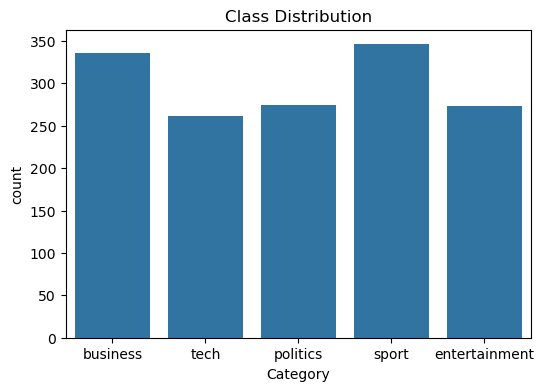

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=train_df)
plt.title("Class Distribution")
plt.show()

## Text Lenght analysis 

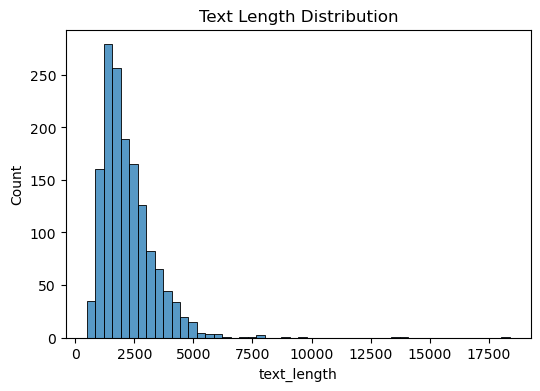

In [15]:
train_df['text_length'] = train_df['Text'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

## Missing values 

In [17]:
train_df.isnull().sum()

ArticleId      0
Text           0
Category       0
text_length    0
dtype: int64

# Text preprocessing 

## Define preprocessing components 

In [20]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [21]:
import re 

def preprocess_text(text):
    """
    This function cleans and normalizes text data.
    Steps:
    1. Lowercase conversion
    2. Remove numbers
    3. Remove punctuation
    4. Remove extra spaces
    5. Stopword removal
    6. Lemmatization
    """
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    words = text.split()
    
    # Stopword removal and lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)


## Apply preprocessing to both training and testing data 

In [23]:
train_df["clean_text"] = train_df["Text"].apply(preprocess_text)
test_df["clean_text"] = test_df["Text"].apply(preprocess_text)

In [24]:
train_df.head()

,ArticleId,Text,Category,text_length,clean_text
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866,worldcom exboss launch defence lawyer defendin...
1,154,german business confidence slides german busin...,business,2016,german business confidence slide german busine...
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104,bbc poll indicates economic gloom citizen majo...
3,1976,lifestyle governs mobile choice faster bett...,tech,3618,lifestyle governs mobile choice faster better ...
4,917,enron bosses in $168m payout eighteen former e...,business,2190,enron boss payout eighteen former enron direct...


# Feature Engineering (TF-IDF)

## TF-IDF Vectorization

In [27]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(train_df["clean_text"])
y = train_df["Category"]

X_test = tfidf.transform(test_df["clean_text"])

In [28]:
print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (1490, 5000)


## Train-Validation Split

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Stratification keeps class balance consistent.
)

# Model Training 

## Multinomial Naive Bayes

In [33]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_val)

## Logistic Regression 

In [35]:
lr_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_val)

## Support Vector Machine (Linear SVM)

In [37]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_val)

# Model Evaluation 

## Metric Calculation Function

In [40]:
from sklearn.preprocessing import label_binarize
def print_metrics(model_name, y_true, y_pred):
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

## Evaluate All Models

In [42]:
print_metrics("Multinomial Naive Bayes", y_val, nb_pred)
print_metrics("Logistic Regression", y_val, lr_pred)
print_metrics("Support Vector Machine", y_val, svm_pred)


Model: Multinomial Naive Bayes
Accuracy : 0.9799
Precision: 0.9799
Recall   : 0.9799
F1-score : 0.9798

Classification Report:

               precision    recall  f1-score   support

     business       0.97      0.97      0.97        67
entertainment       1.00      1.00      1.00        55
     politics       0.96      0.95      0.95        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.98      0.97        52

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298


Model: Logistic Regression
Accuracy : 0.9765
Precision: 0.9765
Recall   : 0.9765
F1-score : 0.9764

Classification Report:

               precision    recall  f1-score   support

     business       0.96      0.99      0.97        67
entertainment       0.98      1.00      0.99        55
     politics       0.98      0.96      0.97        55
        sport       1.00   

## Confusion Matrix

## Naive Bayes

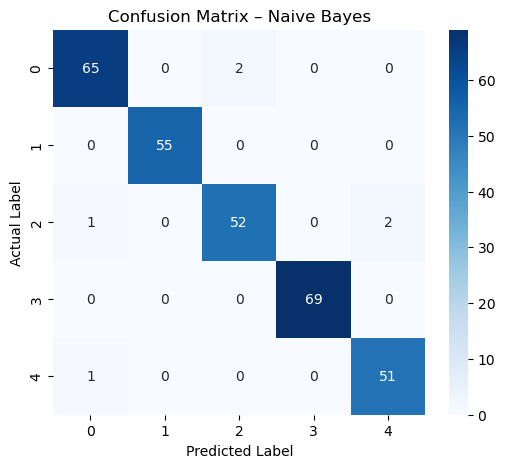

In [45]:
cm_nb = confusion_matrix(y_val, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Logistic Regression

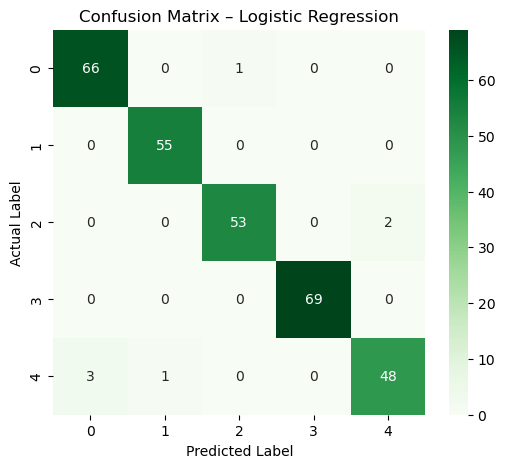

In [47]:
cm_lr = confusion_matrix(y_val, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Support Vector Machine

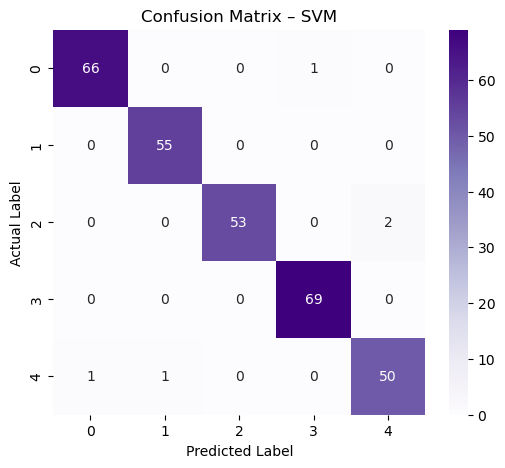

In [49]:
cm_svm = confusion_matrix(y_val, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix – SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# ROC Curve

In [51]:
from sklearn.metrics import roc_curve, auc

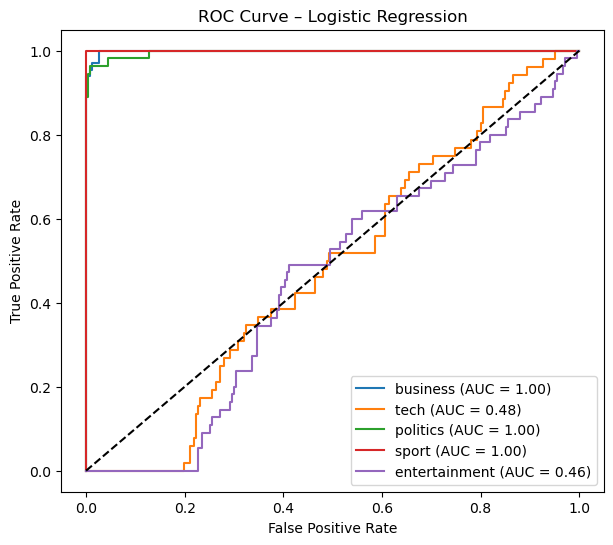

In [52]:
# Binarize labels for ROC
classes = y.unique()
y_val_bin = label_binarize(y_val, classes=classes)

# Use Logistic Regression probabilities
y_score = lr_model.predict_proba(X_val)

plt.figure(figsize=(7,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

# Precision–Recall Curve

In [54]:
from sklearn.metrics import precision_recall_curve

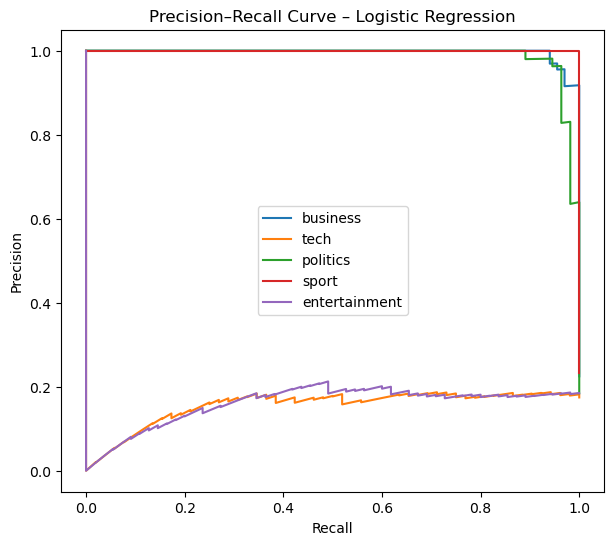

In [55]:
plt.figure(figsize=(7,6))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(
        y_val_bin[:, i], y_score[:, i]
    )
    plt.plot(recall, precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Logistic Regression")
plt.legend()
plt.show()

## Feature Importance / Top Words (Logistic Regression)

In [57]:
feature_names = tfidf.get_feature_names_out()

In [58]:
def plot_top_features(class_label, model, n=10):
    class_index = list(model.classes_).index(class_label)
    coefs = model.coef_[class_index]
    
    top_positive = np.argsort(coefs)[-n:]
    
    plt.figure(figsize=(6,4))
    plt.barh(
        [feature_names[i] for i in top_positive],
        coefs[top_positive]
    )
    plt.title(f"Top Words for Class: {class_label}")
    plt.xlabel("Weight")
    plt.show()

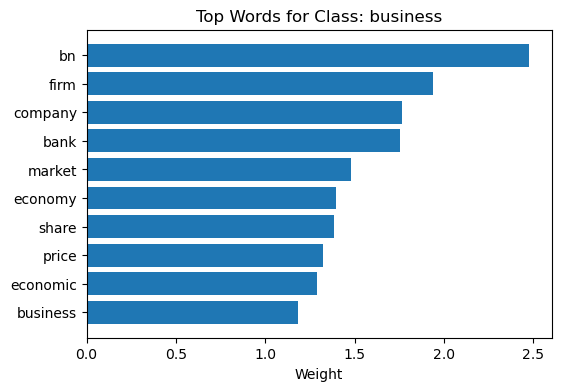

In [59]:
plot_top_features("business", lr_model)

In [60]:
pip install wordcloud

## Word Cloud for Entire Dataset

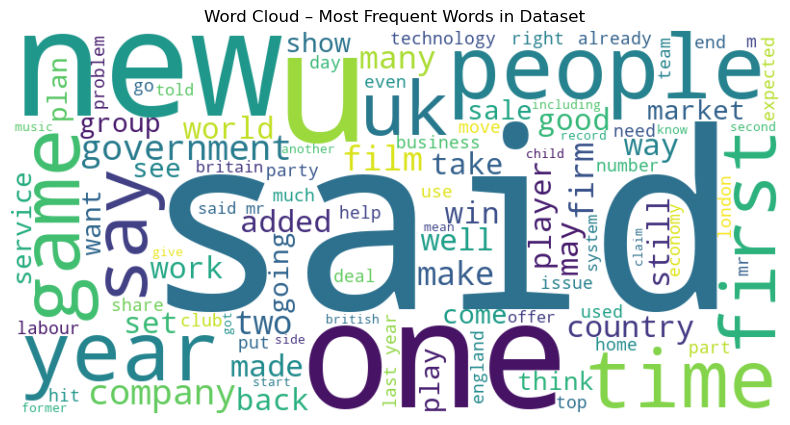

In [62]:
from wordcloud import WordCloud

all_text = " ".join(train_df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Most Frequent Words in Dataset")
plt.show()

## Category-Wise Word Cloud

In [64]:
def plot_category_wordcloud(category):
    text = " ".join(
        train_df[train_df["Category"] == category]["clean_text"]
    )
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=50
    ).generate(text)
    
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud – Category: {category}")
    plt.show()

In [65]:
train_df['Category'].value_counts()

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

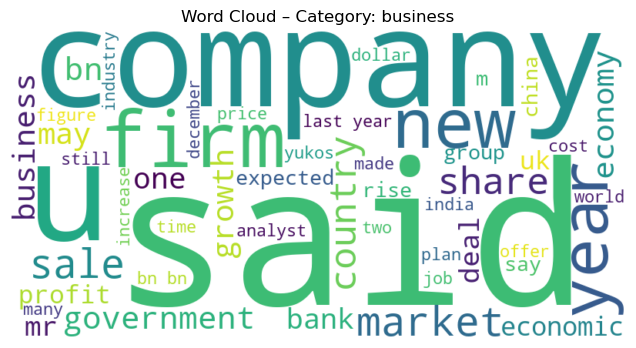

In [66]:
plot_category_wordcloud("business")

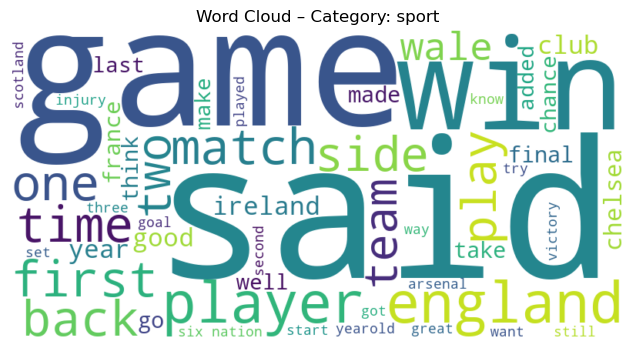

In [67]:
plot_category_wordcloud("sport")

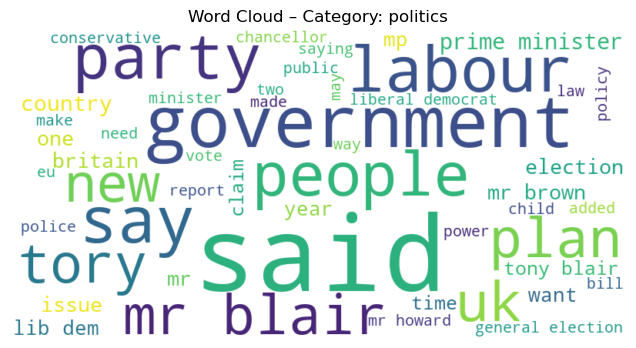

In [68]:
plot_category_wordcloud("politics")

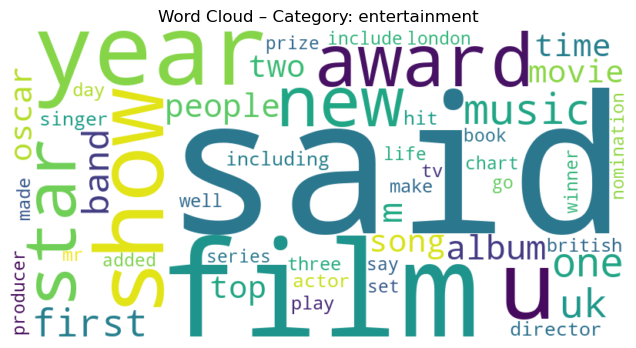

In [69]:
plot_category_wordcloud("entertainment")

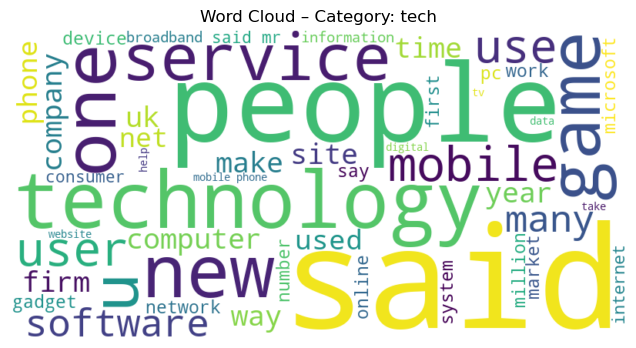

In [70]:
plot_category_wordcloud("tech")

## Sample Predictions

In [72]:
sample_df = train_df.sample(5, random_state=42)

sample_X = tfidf.transform(sample_df["clean_text"])
sample_preds = svm_model.predict(sample_X)

sample_results = pd.DataFrame({
    "Original Text": sample_df["Text"].str[:200] + "...",
    "Actual Label": sample_df["Category"],
    "Predicted Label": sample_preds
})

sample_results

,Original Text,Actual Label,Predicted Label
941,wal-mart is sued over rude lyrics the parents ...,entertainment,entertainment
297,howard taunts blair over splits tony blair s f...,politics,politics
271,fox attacks blair s tory lies tony blair lie...,politics,politics
774,online commons to spark debate online communit...,tech,tech
420,piero gives rugby perspective bbc sport unveil...,tech,tech


## Model comparision Table 

In [74]:
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_val, nb_pred),
        accuracy_score(y_val, lr_pred),
        accuracy_score(y_val, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_val, nb_pred, average="weighted"),
        f1_score(y_val, lr_pred, average="weighted"),
        f1_score(y_val, svm_pred, average="weighted")
    ]
})

comparison_df

,Model,Accuracy,F1 Score
0,Naive Bayes,0.979866,0.979837
1,Logistic Regression,0.976510,0.976380
2,SVM,0.983221,0.983187


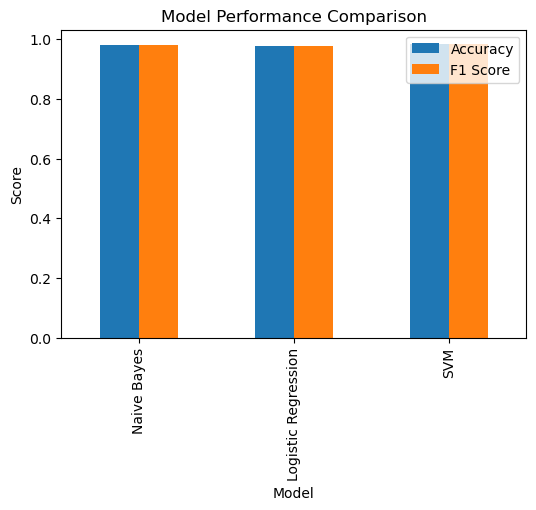

In [75]:
comparison_df.plot(
    x="Model",
    y=["Accuracy", "F1 Score"],
    kind="bar",
    figsize=(6,4),
    title="Model Performance Comparison"
)
plt.ylabel("Score")
plt.show()

## Overfitting & Underfitting Analysis

In [77]:
# Function to calculate train and validation accuracy
def get_train_val_scores(model, X_train, y_train, X_val, y_val):
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    
    return train_acc, val_acc

In [78]:
# Calculate scores for each model
nb_train_acc, nb_val_acc = get_train_val_scores(
    nb_model, X_train, y_train, X_val, y_val
)

lr_train_acc, lr_val_acc = get_train_val_scores(
    lr_model, X_train, y_train, X_val, y_val
)

svm_train_acc, svm_val_acc = get_train_val_scores(
    svm_model, X_train, y_train, X_val, y_val
)

In [79]:
overfit_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Training Accuracy": [
        nb_train_acc, lr_train_acc, svm_train_acc
    ],
    "Validation Accuracy": [
        nb_val_acc, lr_val_acc, svm_val_acc
    ]
})

overfit_df

,Model,Training Accuracy,Validation Accuracy
0,Naive Bayes,0.991611,0.979866
1,Logistic Regression,0.996644,0.976510
2,SVM,1.000000,0.983221


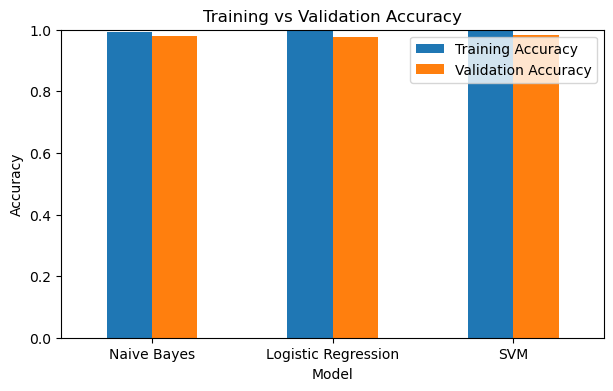

In [80]:
overfit_df.set_index("Model").plot(
    kind="bar",
    figsize=(7,4),
    title="Training vs Validation Accuracy"
)

plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

# Final Testing on Unlabeled Test Dataset

In [82]:
# Predict using the final SVM model
test_predictions = svm_model.predict(X_test)

In [83]:
final_results = pd.DataFrame({
    "ArticleId": test_df["ArticleId"],
    "Predicted_Category": test_predictions,
    "Clean Text": test_df['clean_text']
})

final_results.head()

,ArticleId,Predicted_Category,Clean Text
0,1018,sport,qpr keeper day head preston queen park ranger ...
1,1319,tech,software watching work software monitor every ...
2,1138,sport,arcy injury add ireland woe gordon arcy ruled ...
3,459,business,india reliance family feud heat ongoing public...
4,1020,sport,boro suffer morrison injury blow middlesbrough...


## save prediction 

In [85]:
final_results.to_csv("BBC_News_Test_Predictions.csv", index=False)

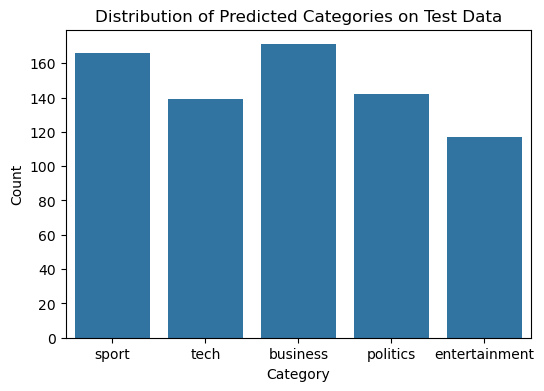

In [86]:
plt.figure(figsize=(6,4))
sns.countplot(x="Predicted_Category", data=final_results)
plt.title("Distribution of Predicted Categories on Test Data")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [87]:
test_df.head()

,ArticleId,Text,clean_text
0,1018,qpr keeper day heads for preston queens park r...,qpr keeper day head preston queen park ranger ...
1,1319,software watching while you work software that...,software watching work software monitor every ...
2,1138,d arcy injury adds to ireland woe gordon d arc...,arcy injury add ireland woe gordon arcy ruled ...
3,459,india s reliance family feud heats up the ongo...,india reliance family feud heat ongoing public...
4,1020,boro suffer morrison injury blow middlesbrough...,boro suffer morrison injury blow middlesbrough...
